In [1]:
from datasets import load_dataset
import pandas as pd

# Load the dataset
dataset = load_dataset("mteb/banking77", split="train")

# Convert to DataFrame
df = pd.DataFrame(dataset)

# Save to CSV
df.to_csv("banking77_dataset.csv", index=False)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/294k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/91.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9993 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3076 [00:00<?, ? examples/s]

In [2]:
# Load the dataset
dataset = load_dataset("mteb/banking77", split="train")

# Convert to DataFrame
df = pd.DataFrame(dataset)

# Save to CSV
df.to_csv("banking77_dataset.csv", index=False)


In [5]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

cleaned_df = remove_outliers(df, 'label')


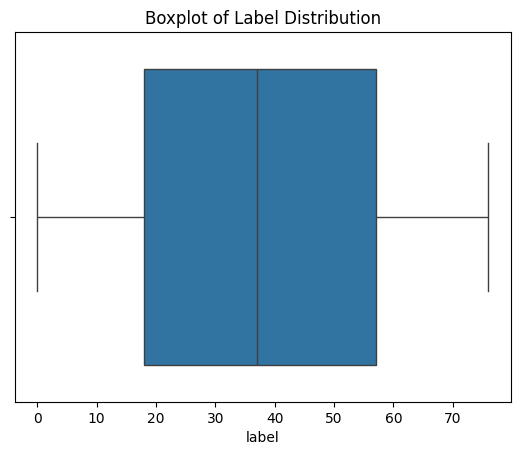

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['label'])
plt.title("Boxplot of Label Distribution")
plt.show()


In [7]:
cleaned_df.to_csv("banking77_cleaned.csv", index=False)